In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_shopping_data.csv to customer_shopping_data.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_shopping_data.csv')
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [ ]:
print(df.shape)
df.info()

(99457, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [ ]:
print(df.isnull().sum())
print(f"\nDublikat sətir sayı: {df.duplicated().sum()}")

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

Dublikat sətir sayı: 0


In [ ]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month

df[['invoice_date', 'year', 'month']].head()

,invoice_date,year,month
0,2022-08-05,2022,8
1,2021-12-12,2021,12
2,2021-11-09,2021,11
3,2021-05-16,2021,5
4,2021-10-24,2021,10


In [ ]:
df['total_revenue'] = df['quantity'] * df['price']
df[['quantity', 'price', 'total_revenue']].head()

,quantity,price,total_revenue
0,5,1500.40,7502.00
1,3,1800.51,5401.53
2,1,300.08,300.08
3,5,3000.85,15004.25
4,4,60.60,242.40


In [ ]:
category_summary = df.groupby('category')['total_revenue'].agg(['sum', 'mean', 'count'])
category_summary = category_summary.sort_values('sum', ascending=False)
category_summary

,sum,mean,count
category,,,
Clothing,1.139968e+08,3305.500364,34487
Shoes,6.655345e+07,6632.793649,10034
Technology,5.786235e+07,11581.735388,4996
Cosmetics,6.792863e+06,449.947864,15097
Toys,3.980426e+06,394.609521,10087
Food & Beverage,8.495351e+05,57.494251,14776
Books,8.345529e+05,167.547260,4981
Souvenir,6.358247e+05,127.190368,4999


In [ ]:
pivot_mall_category = df.pivot_table(
    values='total_revenue',
    index='shopping_mall',
    columns='category',
    aggfunc='sum'
)
pivot_mall_category

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
shopping_mall,,,,,,,,
Cevahir AVM,44541.00,5706321.28,321214.00,44010.45,3243918.85,29723.82,3051300.0,204108.80
Emaar Square Mall,41995.80,5590490.40,338941.76,40610.95,3089675.16,30943.74,3094350.0,179092.48
Forum Istanbul,42056.40,5792444.24,353172.76,39162.24,3327942.65,32879.19,2516850.0,199413.76
Istinye Park,76083.30,11253900.24,655357.88,85918.44,6641481.22,68925.48,5436900.0,400261.12
Kanyon,163029.15,22609527.60,1369550.78,166497.05,13383190.83,127399.53,11944800.0,790236.16
Mall of Istanbul,172240.35,22947417.68,1367517.78,171177.90,13467814.80,127540.29,11828250.0,790522.88
Metrocity,125911.65,17226692.56,991860.04,129902.74,9519296.37,94227.09,8608950.0,605946.88
Metropol AVM,83718.90,11568084.00,680770.38,88638.04,7149825.21,67869.78,5327700.0,413306.88
Viaport Outlet,39632.40,5604594.16,347439.70,41662.18,3194704.91,27319.17,3066000.0,199987.20


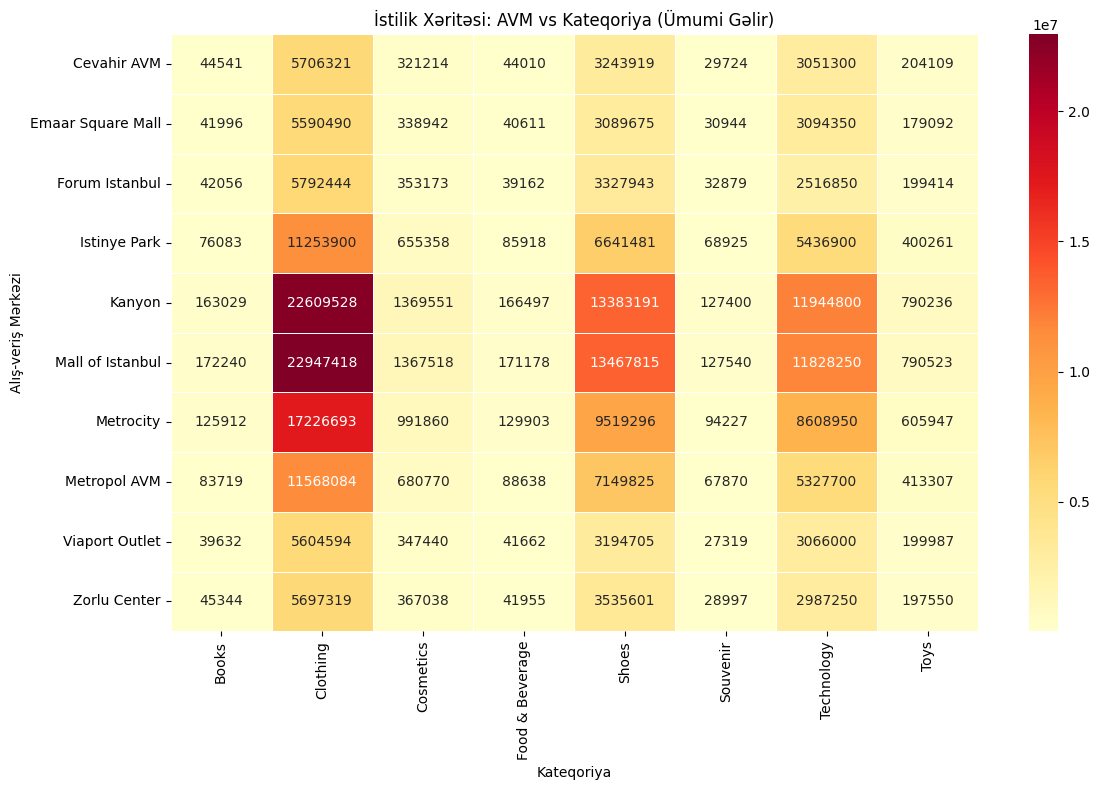

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(pivot_mall_category, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('İstilik Xəritəsi: AVM vs Kateqoriya (Ümumi Gəlir)')
plt.xlabel('Kateqoriya')
plt.ylabel('Alış-veriş Mərkəzi')
plt.tight_layout()
plt.show()

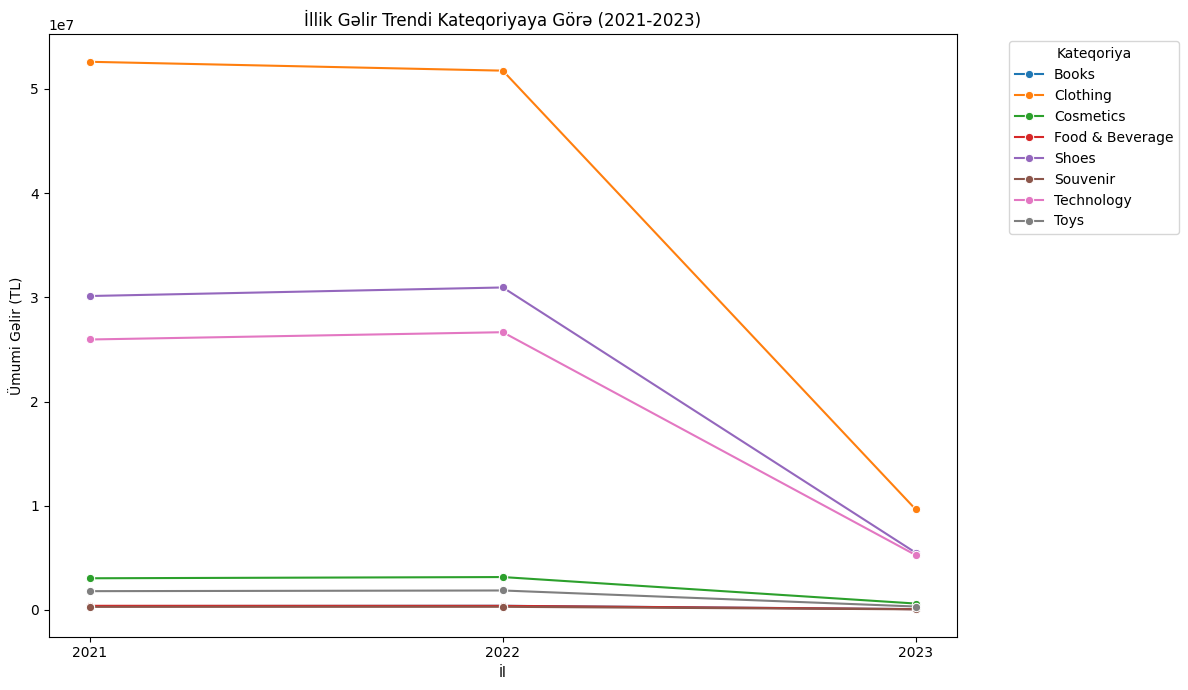

In [ ]:
yearly_category = df.groupby(['year', 'category'])['total_revenue'].sum().reset_index()

plt.figure(figsize=(12,7))
sns.lineplot(data=yearly_category, x='year', y='total_revenue', hue='category', marker='o')
plt.title('İllik Gəlir Trendi Kateqoriyaya Görə (2021-2023)')
plt.xlabel('İl')
plt.ylabel('Ümumi Gəlir (TL)')
plt.legend(title='Kateqoriya', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([2021, 2022, 2023])
plt.tight_layout()
plt.show()

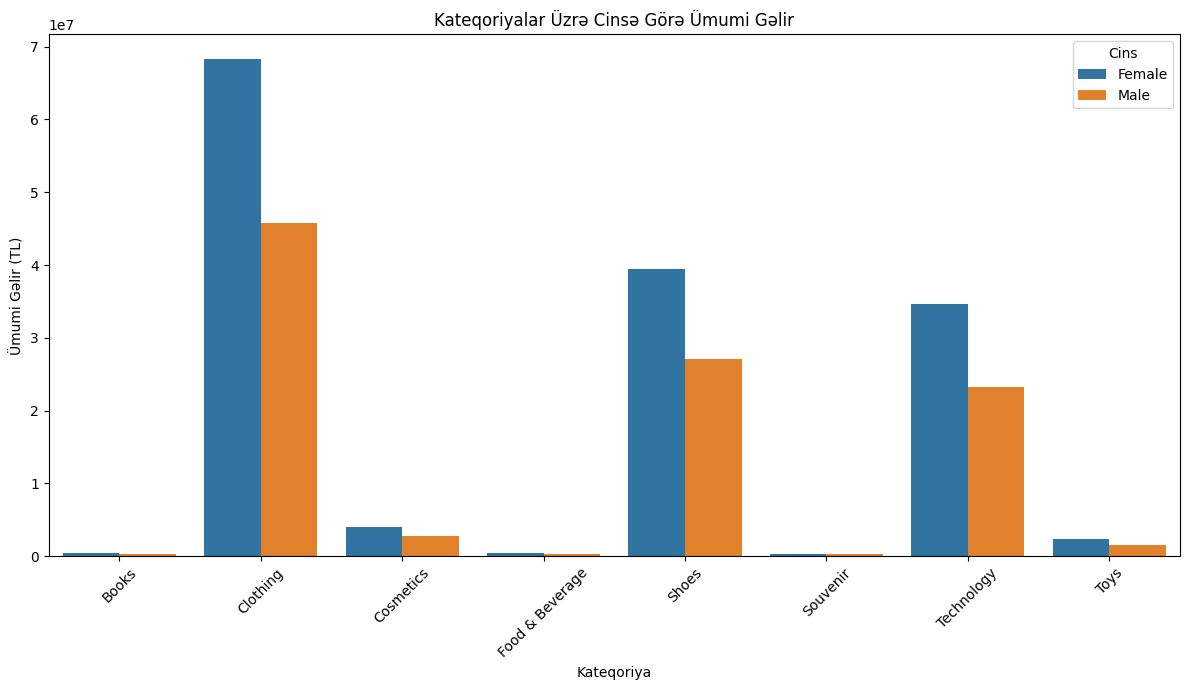

In [ ]:
gender_category = df.groupby(['category', 'gender'])['total_revenue'].sum().reset_index()

plt.figure(figsize=(12,7))
sns.barplot(data=gender_category, x='category', y='total_revenue', hue='gender')
plt.title('Kateqoriyalar Üzrə Cinsə Görə Ümumi Gəlir')
plt.xlabel('Kateqoriya')
plt.ylabel('Ümumi Gəlir (TL)')
plt.xticks(rotation=45)
plt.legend(title='Cins')
plt.tight_layout()
plt.show()

In [ ]:
monthly_mall = df.groupby(['shopping_mall', 'year', 'month'])['total_revenue'].sum().reset_index()
monthly_mall = monthly_mall.sort_values(['shopping_mall', 'year', 'month'])

monthly_mall['growth_rate_%'] = monthly_mall.groupby('shopping_mall')['total_revenue'].pct_change() * 100

monthly_mall.head(15)

,shopping_mall,year,month,total_revenue,growth_rate_%
0,Cevahir AVM,2021,1,483830.06,NaN
1,Cevahir AVM,2021,2,329264.45,-31.946260
2,Cevahir AVM,2021,3,512891.12,55.768751
3,Cevahir AVM,2021,4,432312.84,-15.710602
4,Cevahir AVM,2021,5,489344.99,13.192333
5,Cevahir AVM,2021,6,400583.19,-18.138900
6,Cevahir AVM,2021,7,547457.71,36.665173
7,Cevahir AVM,2021,8,423705.15,-22.604953
8,Cevahir AVM,2021,9,488999.18,15.410252
9,Cevahir AVM,2021,10,537142.92,9.845362


In [ ]:
payment_by_category = df.groupby(['category', 'payment_method']).size().reset_index(name='count')

top_payment = payment_by_category.loc[payment_by_category.groupby('category')['count'].idxmax()]
top_payment = top_payment.sort_values('count', ascending=False)
top_payment

,category,payment_method,count
3,Clothing,Cash,15456
6,Cosmetics,Cash,6674
9,Food & Beverage,Cash,6587
21,Toys,Cash,4542
12,Shoes,Cash,4474
0,Books,Cash,2268
18,Technology,Cash,2235
15,Souvenir,Cash,2211


In [ ]:
payment_summary = df.groupby('payment_method')['total_revenue'].agg(['sum', 'mean', 'count'])
payment_summary = payment_summary.sort_values('sum', ascending=False)
payment_summary

,sum,mean,count
payment_method,,,
Cash,1.128322e+08,2538.579500,44447
Credit Card,8.807712e+07,2521.460129,34931
Debit Card,5.059643e+07,2519.867895,20079


Biznes Anlayislari

1. Geyim  kateqoriyasi umumi gelirin en boyuk hissesini (~114 milyon TL) teskil edir, bu da AVM idarechiliyinin esas diqqetini bu kateqoriyaya yoneltmeli oldugunu gosterir.

2. Texnologiya bolmesinde orta alish meblegi ( 11581 TL) butun kateqoriyalar arasinda en yuksekdir, baxmayaraq ki, emeliyyat sayi azdir. Bu, az sayda amma yuksek deyerli satishlar gelire guclu tesir etdiyini gosterir.

3. Kanyon ve Mall of Istanbul AVM-leri, xususile Geyim bolmesinde diger AVM-lerden qat-qat yuksek gelir elde edir. Bu iki merkez esas gelir menbeyi kimi xususi diqqetle idare olunmalidir.

4. Qadin musteriler butun kateqoriyalarda kishilerden daha chox xercleyir (texminen 60/40 nisbetinde). Marketinq strategiyalari qadin musteri seqmentine uygunlashdirila biler.

5. Naghd odenish butun kateqoriyalarda en chox istifade olunan odenish usuludur. Bu, kart odenishlerini teshviq eden kampaniyalarin (meselen kart endirimleri) tetbiqi uchun imkan yarada biler.

